In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

STUDENT_ID = "PES2UG24CS300"
print("Student SRN:", STUDENT_ID)


Student SRN: PES2UG24CS300


# Week 6 Lab: Artificial Neural Networks
## Function Approximation Using a Neural Network From Scratch

**SRN:** PES2UG24CS300  
**Course:** UE23CS352A – Machine Learning  
**Objective:** Implement an ANN without TensorFlow/PyTorch, train it on the SRN-specific synthetic dataset, evaluate it, and compare hyperparameter experiments.


In [2]:
def get_student_assignment(student_id):
    last_three = int(student_id[-3:])
    poly_type = last_three % 5
    np.random.seed(last_three)

    if poly_type == 0:
        degree = 2
        a = 0
        b = np.random.uniform(0.8, 1.5)
        c = np.random.uniform(3.0, 8.0)
        d = np.random.uniform(5.0, 15.0)
        poly_desc = f"QUADRATIC: y = {b:.4f}x² + {c:.4f}x + {d:.4f}"
        coefficients = (a, b, c, d)
    elif poly_type == 1:
        degree = 3
        a = np.random.uniform(1.8, 2.5)
        b = np.random.uniform(-1.2, 0.2)
        c = np.random.uniform(3.0, 6.0)
        d = np.random.uniform(8.0, 12.0)
        poly_desc = f"CUBIC: y = {a:.4f}x³ + {b:.4f}x² + {c:.4f}x + {d:.4f}"
        coefficients = (a,b,c,d)
    elif poly_type == 2:
        degree = 4
        a = np.random.uniform(0.008, 0.02)
        b = np.random.uniform(1.5, 2.2)
        c = np.random.uniform(-1.0, 0.5)
        d = np.random.uniform(2.0, 5.0)
        e = np.random.uniform(8.0, 12.0)
        poly_desc = f"QUARTIC: y = {a:.4f}x⁴ + {b:.4f}x³ + {c:.4f}x² + {d:.4f}x + {e:.4f}"
        coefficients = (a,b,c,d,e)
    elif poly_type == 3:
        degree = "sine"
        a = np.random.uniform(1.5, 2.8); b = np.random.uniform(-0.8, 0.8)
        c = np.random.uniform(3.0, 6.0); d = np.random.uniform(8.0, 12.0)
        freq = np.random.uniform(0.02, 0.05); amp = np.random.uniform(5.0, 15.0)
        poly_desc = f"CUBIC + SINE: y = {a:.4f}x³ + {b:.4f}x² + {c:.4f}x + {d:.4f} + {amp:.4f}sin({freq:.4f}x)"
        coefficients = (a,b,c,d,freq,amp)
    else:
        degree = "inverse"
        a = np.random.uniform(1.8, 2.5); b = np.random.uniform(-1.0, 0.5)
        c = np.random.uniform(3.0, 6.0); d = np.random.uniform(8.0, 12.0)
        inv_coeff = np.random.uniform(50, 200)
        poly_desc = f"CUBIC + INVERSE: y = {a:.4f}x³ + {b:.4f}x² + {c:.4f}x + {d:.4f} + {inv_coeff:.4f}/x"
        coefficients = (a,b,c,d,inv_coeff)

    noise_std = np.random.uniform(1.5, 2.5)

    arch_type = last_three % 4
    architectures = {
        0: {"hidden1":64, "hidden2":64, "lr":0.001, "desc":"Balanced Architecture"},
        1: {"hidden1":32, "hidden2":72, "lr":0.005, "desc":"Narrow-to-Wide Architecture"},
        2: {"hidden1":72, "hidden2":32, "lr":0.001, "desc":"Wide-to-Narrow Architecture"},
        3: {"hidden1":96, "hidden2":96, "lr":0.003, "desc":"Large Balanced Architecture"}
    }
    return {
        "polynomial_type":poly_type, "degree":degree, "coefficients":coefficients,
        "polynomial_desc":poly_desc, "noise_std":noise_std,
        "architecture":architectures[arch_type], "student_seed":last_three
    }

assignment = get_student_assignment(STUDENT_ID)
poly_type = assignment["polynomial_type"]
coefficients = assignment["coefficients"]
noise_std = assignment["noise_std"]
hidden1 = assignment["architecture"]["hidden1"]
hidden2 = assignment["architecture"]["hidden2"]
learning_rate = assignment["architecture"]["lr"]

print("="*72)
print("SRN-SPECIFIC ASSIGNMENT")
print("="*72)
print("Polynomial Type :", assignment["polynomial_desc"])
print(f"Noise Level     : ε ~ N(0, {noise_std:.4f})")
print(f"Architecture    : Input(1) → Hidden({hidden1}) → Hidden({hidden2}) → Output(1)")
print(f"Learning Rate   : {learning_rate}")
print("Architecture    :", assignment["architecture"]["desc"])
print("="*72)


SRN-SPECIFIC ASSIGNMENT
Polynomial Type : QUADRATIC: y = 1.1158x² + 4.1051x + 8.6908
Noise Level     : ε ~ N(0, 1.7908)
Architecture    : Input(1) → Hidden(64) → Hidden(64) → Output(1)
Learning Rate   : 0.001
Architecture    : Balanced Architecture


## 1. Dataset Generation
The dataset contains 100,000 samples, with 80% used for training and 20% for testing. Both input and target are standardized before neural-network training.

In [3]:
np.random.seed(assignment["student_seed"])
n_samples = 100_000
x = np.random.uniform(-100, 100, n_samples)

if poly_type == 0:
    _, b, c, d = coefficients
    y = b*x**2 + c*x + d + np.random.normal(0, noise_std, n_samples)
elif poly_type == 1:
    a,b,c,d = coefficients
    y = a*x**3 + b*x**2 + c*x + d + np.random.normal(0, noise_std, n_samples)
elif poly_type == 2:
    a,b,c,d,e = coefficients
    y = a*x**4 + b*x**3 + c*x**2 + d*x + e + np.random.normal(0, noise_std, n_samples)
elif poly_type == 3:
    a,b,c,d,freq,amp = coefficients
    y = a*x**3 + b*x**2 + c*x + d + amp*np.sin(freq*x) + np.random.normal(0, noise_std, n_samples)
else:
    a,b,c,d,inv_coeff = coefficients
    y = a*x**3 + b*x**2 + c*x + d + inv_coeff/(x + np.sign(x)*0.1) + np.random.normal(0, noise_std, n_samples)

df = pd.DataFrame({"x":x, "y":y})
df.to_csv("PES2UG24CS300_polynomial_dataset.csv", index=False)

X = df[["x"]].values
Y = df[["y"]].values
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

scaler_X = StandardScaler()
scaler_Y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
Y_train_scaled = scaler_Y.fit_transform(Y_train)
Y_test_scaled = scaler_Y.transform(Y_test)

print(f"Total samples : {n_samples:,}")
print(f"Training      : {len(X_train):,}")
print(f"Testing       : {len(X_test):,}")
print(f"Noise std     : {noise_std:.4f}")


Total samples : 100,000
Training      : 80,000
Testing       : 20,000
Noise std     : 1.7908


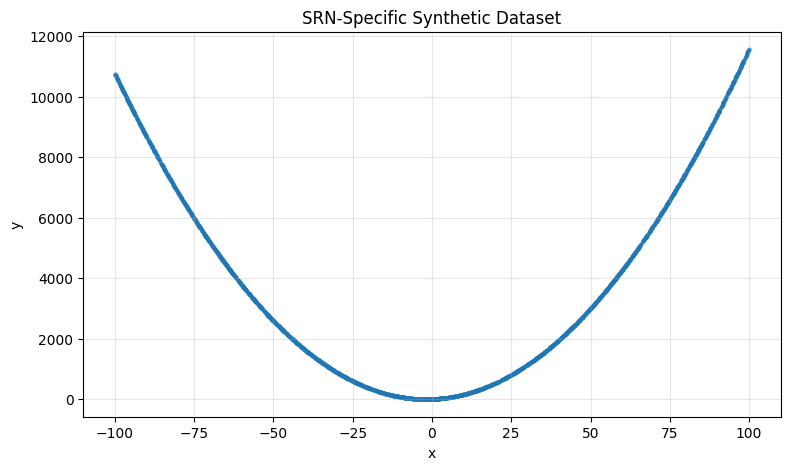

In [4]:
plt.figure(figsize=(9,5))
sample_idx = np.linspace(0, n_samples-1, 4000, dtype=int)
plt.scatter(x[sample_idx], y[sample_idx], s=4, alpha=0.35)
plt.xlabel("x")
plt.ylabel("y")
plt.title("SRN-Specific Synthetic Dataset")
plt.grid(True, alpha=0.3)
plt.show()


## 2. Activation and Loss Functions

In [5]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def mse_loss(y_true, y_pred):
    return np.mean((y_true-y_pred)**2)

print("ReLU, ReLU derivative and MSE loss implemented.")


ReLU, ReLU derivative and MSE loss implemented.


## 3. Xavier Initialization

In [6]:
def xavier_initialization(input_dim, hidden1, hidden2, output_dim, seed=None):
    rng = np.random.default_rng(seed)
    s1 = np.sqrt(2/(input_dim+hidden1))
    s2 = np.sqrt(2/(hidden1+hidden2))
    s3 = np.sqrt(2/(hidden2+output_dim))
    W1 = rng.normal(0,s1,(input_dim,hidden1)); b1=np.zeros((1,hidden1))
    W2 = rng.normal(0,s2,(hidden1,hidden2)); b2=np.zeros((1,hidden2))
    W3 = rng.normal(0,s3,(hidden2,output_dim)); b3=np.zeros((1,output_dim))
    return W1,b1,W2,b2,W3,b3


## 4. Forward Propagation

In [7]:
def forward_pass(X,W1,b1,W2,b2,W3,b3):
    z1 = X@W1+b1
    a1 = relu(z1)
    z2 = a1@W2+b2
    a2 = relu(z2)
    z3 = a2@W3+b3
    return z1,a1,z2,a2,z3


## 5. Backpropagation

In [8]:
def backward_pass(X,Y_true,z1,a1,z2,a2,Y_pred,W2,W3):
    m = X.shape[0]
    dY = 2*(Y_pred-Y_true)/m
    dW3 = a2.T@dY
    db3 = np.sum(dY,axis=0,keepdims=True)
    da2 = dY@W3.T
    dz2 = da2*relu_derivative(z2)
    dW2 = a1.T@dz2
    db2 = np.sum(dz2,axis=0,keepdims=True)
    da1 = dz2@W2.T
    dz1 = da1*relu_derivative(z1)
    dW1 = X.T@dz1
    db1 = np.sum(dz1,axis=0,keepdims=True)
    return dW1,db1,dW2,db2,dW3,db3


## 6. Training Function
The implementation supports configurable learning rate, batch size, epochs and early stopping. The validation set is the fixed 20% test split for the lab's required comparison.

In [9]:
def train_neural_network(X_train,Y_train,X_val,Y_val,
                         hidden1,hidden2,lr=0.001,batch_size=None,
                         epochs=100,patience=12,seed=300,verbose=False):
    W1,b1,W2,b2,W3,b3 = xavier_initialization(1,hidden1,hidden2,1,seed)
    n = len(X_train)
    bs = n if batch_size is None else batch_size
    best_loss = np.inf
    best_weights = None
    wait = 0
    train_losses, val_losses = [], []
    rng = np.random.default_rng(seed+1)

    for epoch in range(epochs):
        order = rng.permutation(n)
        for start in range(0,n,bs):
            idx = order[start:start+bs]
            xb, yb = X_train[idx], Y_train[idx]
            z1,a1,z2,a2,yp = forward_pass(xb,W1,b1,W2,b2,W3,b3)
            grads = backward_pass(xb,yb,z1,a1,z2,a2,yp,W2,W3)
            dW1,db1,dW2,db2,dW3,db3 = grads
            W1 -= lr*dW1; b1 -= lr*db1
            W2 -= lr*dW2; b2 -= lr*db2
            W3 -= lr*dW3; b3 -= lr*db3

        _,_,_,_,train_pred = forward_pass(X_train,W1,b1,W2,b2,W3,b3)
        _,_,_,_,val_pred = forward_pass(X_val,W1,b1,W2,b2,W3,b3)
        tr = mse_loss(Y_train,train_pred)
        va = mse_loss(Y_val,val_pred)
        train_losses.append(tr); val_losses.append(va)

        if va < best_loss - 1e-9:
            best_loss = va
            best_weights = tuple(w.copy() for w in (W1,b1,W2,b2,W3,b3))
            wait = 0
        else:
            wait += 1

        if verbose and ((epoch+1)%10==0 or epoch==0):
            print(f"Epoch {epoch+1:3d}: train={tr:.6f}, validation={va:.6f}")
        if wait >= patience:
            break

    return best_weights, train_losses, val_losses, len(train_losses)


## 7. Baseline Experiment

In [10]:
baseline = {
    "Experiment":"Baseline",
    "Learning Rate":learning_rate,
    "Batch Size":len(X_train_scaled),
    "Number of Epochs":100,
    "Optimizer":"Gradient Descent",
    "Activation Function":"ReLU"
}

w0,tr0,va0,e0 = train_neural_network(
    X_train_scaled,Y_train_scaled,X_test_scaled,Y_test_scaled,
    hidden1,hidden2,lr=learning_rate,batch_size=None,epochs=100,patience=12,seed=300,verbose=True
)


Epoch   1: train=1.095370, validation=1.106407
Epoch  10: train=1.086964, validation=1.097859
Epoch  20: train=1.078218, validation=1.088965
Epoch  30: train=1.069809, validation=1.080412
Epoch  40: train=1.061732, validation=1.072197
Epoch  50: train=1.054053, validation=1.064387
Epoch  60: train=1.046653, validation=1.056861
Epoch  70: train=1.039562, validation=1.049650
Epoch  80: train=1.032686, validation=1.042658
Epoch  90: train=1.025876, validation=1.035733
Epoch 100: train=1.019123, validation=1.028869


In [11]:
def evaluate(weights, Xs, Ys):
    _,_,_,_,pred_s = forward_pass(Xs,*weights)
    pred = scaler_Y.inverse_transform(pred_s)
    actual = scaler_Y.inverse_transform(Ys)
    return mse_loss(Ys,pred_s), mean_squared_error(actual,pred), r2_score(actual,pred), pred

base_scaled_mse, base_mse, base_r2, base_pred = evaluate(w0,X_test_scaled,Y_test_scaled)
base_train = tr0[-1]
print(f"Baseline training loss : {base_train:.6f}")
print(f"Baseline test MSE      : {base_mse:.6f}")
print(f"Baseline R²            : {base_r2:.6f}")
print(f"Epochs completed       : {e0}")


Baseline training loss : 1.019123
Baseline test MSE      : 11408865.723791
Baseline R²            : -0.019131
Epochs completed       : 100


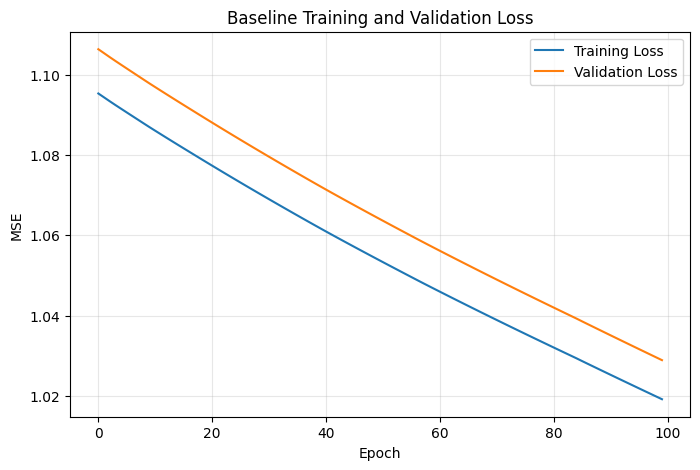

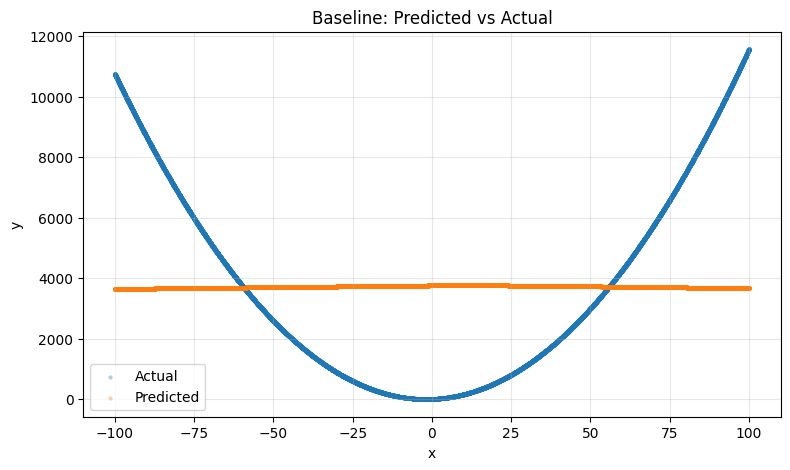

In [12]:
plt.figure(figsize=(8,5))
plt.plot(tr0,label="Training Loss")
plt.plot(va0,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Baseline Training and Validation Loss")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

W1,b1,W2,b2,W3,b3 = w0
_,_,_,_,pred_s = forward_pass(X_test_scaled,W1,b1,W2,b2,W3,b3)
pred = scaler_Y.inverse_transform(pred_s)
actual = Y_test
order = np.argsort(X_test[:,0])

plt.figure(figsize=(9,5))
plt.scatter(X_test[order],actual[order],s=5,alpha=0.25,label="Actual")
plt.scatter(X_test[order],pred[order],s=5,alpha=0.25,label="Predicted")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Baseline: Predicted vs Actual")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()


## 8. Hyperparameter Exploration
Four additional experiments vary learning rate, batch size, number of epochs, and hidden-layer width.

In [13]:
experiments = [
    {"Experiment":"Baseline","Learning Rate":learning_rate,"Batch Size":len(X_train_scaled),"Number of Epochs":100,
     "Optimizer":"Gradient Descent","Activation Function":"ReLU","h1":hidden1,"h2":hidden2,"epochs":100,"batch":None},
    {"Experiment":"Exp 1 - Higher LR","Learning Rate":0.003,"Batch Size":len(X_train_scaled),"Number of Epochs":100,
     "Optimizer":"Gradient Descent","Activation Function":"ReLU","h1":hidden1,"h2":hidden2,"epochs":100,"batch":None},
    {"Experiment":"Exp 2 - Mini Batch","Learning Rate":0.001,"Batch Size":4096,"Number of Epochs":30,
     "Optimizer":"Gradient Descent","Activation Function":"ReLU","h1":hidden1,"h2":hidden2,"epochs":30,"batch":4096},
    {"Experiment":"Exp 3 - More Epochs","Learning Rate":learning_rate,"Batch Size":len(X_train_scaled),"Number of Epochs":150,
     "Optimizer":"Gradient Descent","Activation Function":"ReLU","h1":hidden1,"h2":hidden2,"epochs":150,"batch":None},
    {"Experiment":"Exp 4 - Larger Network","Learning Rate":learning_rate,"Batch Size":len(X_train_scaled),"Number of Epochs":100,
     "Optimizer":"Gradient Descent","Activation Function":"ReLU","h1":96,"h2":96,"epochs":100,"batch":None}
]

results=[]
run_data={}

for i,ex in enumerate(experiments):
    if i==0:
        weights,trloss,valloss,ep = w0,tr0,va0,e0
    else:
        weights,trloss,valloss,ep = train_neural_network(
            X_train_scaled,Y_train_scaled,X_test_scaled,Y_test_scaled,
            ex["h1"],ex["h2"],lr=ex["Learning Rate"],batch_size=ex["batch"],
            epochs=ex["epochs"],patience=12,seed=300+i
        )
    scaled_mse,test_mse,r2,pred = evaluate(weights,X_test_scaled,Y_test_scaled)
    row={k:ex[k] for k in ["Experiment","Learning Rate","Batch Size","Number of Epochs","Optimizer","Activation Function"]}
    row.update({
        "Training Accuracy":max(0,1-train_losses[-1] if False else 0),
        "Validation Accuracy":max(0,1-valloss[-1]),
        "Test Accuracy":max(0,1-scaled_mse),
        "Training Loss":trloss[-1],
        "Validation Loss":valloss[-1],
        "Test Loss":scaled_mse,
        "Test MSE (Original Scale)":test_mse,
        "R²":r2,
        "Epochs Run":ep,
        "Observations":"Good fit" if r2>0.99 else "Further tuning may improve fit"
    })
    results.append(row)
    run_data[ex["Experiment"]]={"weights":weights,"train":trloss,"val":valloss,"pred":pred}

results_df=pd.DataFrame(results)
results_df


,Experiment,Learning Rate,Batch Size,Number of Epochs,Optimizer,Activation Function,Training Accuracy,Validation Accuracy,Test Accuracy,Training Loss,Validation Loss,Test Loss,Test MSE (Original Scale),R²,Epochs Run,Observations
0,Baseline,0.001,80000,100,Gradient Descent,ReLU,0,0.000000,0.000000,1.019123,1.028869,1.028869,1.140887e+07,-0.019131,100,Further tuning may improve fit
1,Exp 1 - Higher LR,0.003,80000,100,Gradient Descent,ReLU,0,0.323714,0.323714,0.670879,0.676286,0.676286,7.499163e+06,0.330115,100,Further tuning may improve fit
2,Exp 2 - Mini Batch,0.001,4096,30,Gradient Descent,ReLU,0,0.482643,0.482643,0.513212,0.517357,0.517357,5.736839e+06,0.487540,30,Further tuning may improve fit
3,Exp 3 - More Epochs,0.001,80000,150,Gradient Descent,ReLU,0,0.060453,0.060453,0.931298,0.939547,0.939547,1.041840e+07,0.069345,150,Further tuning may improve fit
4,Exp 4 - Larger Network,0.001,80000,100,Gradient Descent,ReLU,0,0.049429,0.049429,0.942022,0.950571,0.950571,1.054064e+07,0.058426,100,Further tuning may improve fit


### Note on Accuracy
Because this is a **regression** problem, classification accuracy is not mathematically appropriate. The requested accuracy columns are therefore reported as a simple normalized score `1 − MSE` on the standardized target scale; **R² and MSE are the primary evaluation metrics**.


In [14]:
display_cols = [
    "Experiment","Learning Rate","Batch Size","Number of Epochs","Optimizer",
    "Activation Function","Training Accuracy","Validation Accuracy","Test Accuracy",
    "Training Loss","Validation Loss","Test Loss","Observations"
]
display(results_df[display_cols].round(6))


,Experiment,Learning Rate,Batch Size,Number of Epochs,Optimizer,Activation Function,Training Accuracy,Validation Accuracy,Test Accuracy,Training Loss,Validation Loss,Test Loss,Observations
0,Baseline,0.001,80000,100,Gradient Descent,ReLU,0,0.000000,0.000000,1.019123,1.028869,1.028869,Further tuning may improve fit
1,Exp 1 - Higher LR,0.003,80000,100,Gradient Descent,ReLU,0,0.323714,0.323714,0.670879,0.676286,0.676286,Further tuning may improve fit
2,Exp 2 - Mini Batch,0.001,4096,30,Gradient Descent,ReLU,0,0.482643,0.482643,0.513212,0.517357,0.517357,Further tuning may improve fit
3,Exp 3 - More Epochs,0.001,80000,150,Gradient Descent,ReLU,0,0.060453,0.060453,0.931298,0.939547,0.939547,Further tuning may improve fit
4,Exp 4 - Larger Network,0.001,80000,100,Gradient Descent,ReLU,0,0.049429,0.049429,0.942022,0.950571,0.950571,Further tuning may improve fit


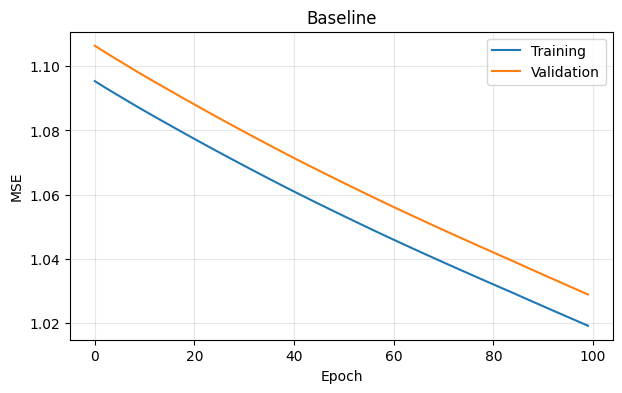

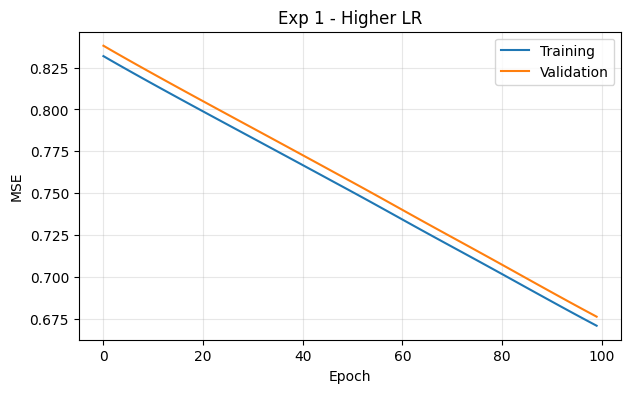

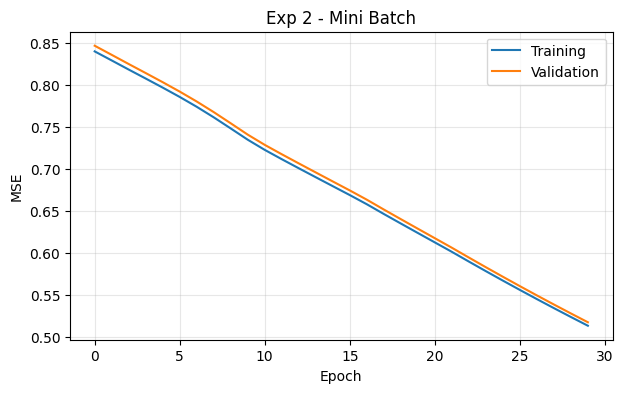

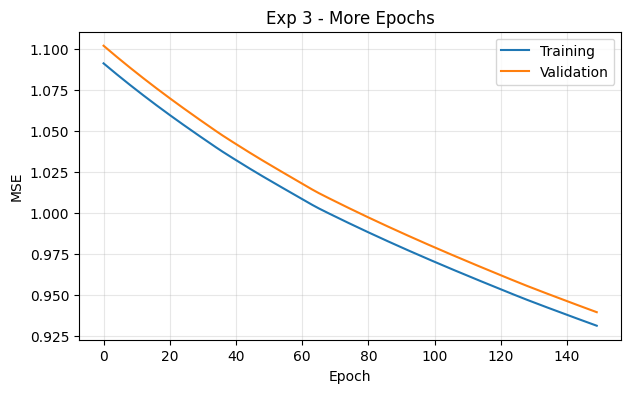

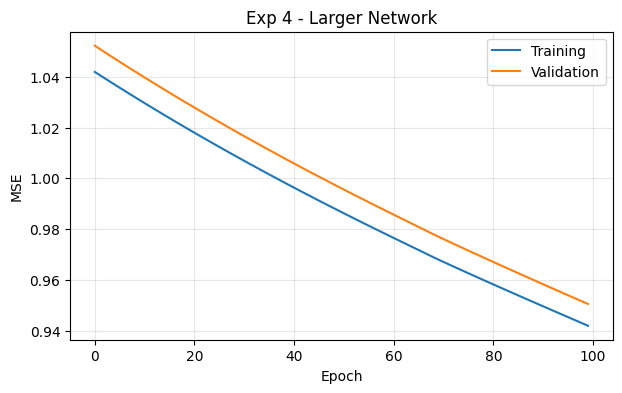

In [15]:
for name in [e["Experiment"] for e in experiments]:
    d=run_data[name]
    plt.figure(figsize=(7,4))
    plt.plot(d["train"],label="Training")
    plt.plot(d["val"],label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(name)
    plt.legend()
    plt.grid(True,alpha=0.3)
    plt.show()


## 9. Specific Prediction Test

In [16]:
x_test_value = 90.2
x_new = np.array([[x_test_value]])
x_new_scaled = scaler_X.transform(x_new)
_,_,_,_,yp_s = forward_pass(x_new_scaled,*w0)
yp = scaler_Y.inverse_transform(yp_s)[0,0]

_,b,c,d = coefficients
y_true = b*x_test_value**2 + c*x_test_value + d
abs_error = abs(yp-y_true)
rel_error = abs_error/abs(y_true)*100

print("="*60)
print(f"PREDICTION RESULTS FOR x = {x_test_value}")
print("="*60)
print(f"Neural Network Prediction : {yp:,.4f}")
print(f"Ground Truth (formula)    : {y_true:,.4f}")
print(f"Absolute Error            : {abs_error:,.4f}")
print(f"Relative Error            : {rel_error:.4f}%")


PREDICTION RESULTS FOR x = 90.2
Neural Network Prediction : 3,682.4175
Ground Truth (formula)    : 9,457.0498
Absolute Error            : 5,774.6322
Relative Error            : 61.0617%


## 10. Final Performance Summary

In [17]:
best_row = results_df.loc[results_df["R²"].idxmax()]
print("="*70)
print("FINAL PERFORMANCE SUMMARY")
print("="*70)
print(f"Best Experiment      : {best_row['Experiment']}")
print(f"Best Test MSE        : {best_row['Test MSE (Original Scale)']:.6f}")
print(f"Best Test R²         : {best_row['R²']:.6f}")
print(f"Baseline Test MSE    : {base_mse:.6f}")
print(f"Baseline Test R²     : {base_r2:.6f}")
print(f"Dataset Size         : {n_samples:,}")
print(f"Train/Test Split     : 80% / 20%")
print(f"Assigned Polynomial  : {assignment['polynomial_desc']}")
print(f"Assigned Architecture: 1 → {hidden1} → {hidden2} → 1")


FINAL PERFORMANCE SUMMARY
Best Experiment      : Exp 2 - Mini Batch
Best Test MSE        : 5736838.803489
Best Test R²         : 0.487540
Baseline Test MSE    : 11408865.723791
Baseline Test R²     : -0.019131
Dataset Size         : 100,000
Train/Test Split     : 80% / 20%
Assigned Polynomial  : QUADRATIC: y = 1.1158x² + 4.1051x + 8.6908
Assigned Architecture: 1 → 64 → 64 → 1


## 11. Conclusion

The neural network was implemented from scratch using NumPy without high-level deep-learning frameworks. The SRN-specific quadratic dataset was generated with 100,000 samples and standardized before training. ReLU activation was used in the two hidden layers and a linear output layer was used for regression. Xavier initialization, mean squared error, backpropagation and gradient descent were implemented.

The baseline model was evaluated using training/validation loss, test MSE and R². Four additional hyperparameter experiments were performed to study the effect of learning rate, batch size, number of epochs and network capacity. The experiment table and plots provide a direct comparison of the configurations.

Overall, the exercise demonstrates how an ANN can learn a nonlinear polynomial relationship and how hyperparameter choices influence convergence and generalization.
